# Exporting and reading the scan from hdf5

This notebook shows how to export a scan to `.h5` (HDF5, the Hierarchical Data
Format version 5). An HDF5 file holds large numerical datasets and the metadata
that describes them in a single file, arranged in a directory-like structure:
groups behave like folders, datasets like files, and attributes attach small
values — units, labels, settings — to either.

This gives us a couple of advantages. The file is much smaller: the source CSV here is 4.5 MB
and the `.h5` is 0.14 MB, with nothing discarded. And the data is read from disk
only when asked for, so a slice of a large dataset costs only that slice in
memory rather than the whole array. This dataset is small enough that the memory
point does not matter in practice, but the mechanism is shown below.

One thing to keep in mind throughout: the archive stores the counts as the
instrument file had them. The Jacobian conversion and the background subtraction
applied when loading are recorded as metadata but not baked into the arrays, so
plots built straight from the stored spectra need those steps redone. This is a deliberate choice: all corrections applied to the data must be **opt-in**.

We will cover
1. Reading the scan from `.csv` and exporting it to `.h5`
2. Inspecting the exported `.h5` file directly with `h5py`
3. Reading the `.h5` file back into a scan object

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tmdc_optics_tools as tmdc
from cmcrameri import cm  
from pathlib import Path
import h5py
from tmdc_optics_tools import processing

## Loading metadata and the scan

The dataset we are using is the same found in `examples/example_stark_shift.ipynb`.

In [2]:
sample_geometry = tmdc.DeviceGeometry(
    tmdc_stack = [
        tmdc.StackLayer("MoSe2"),
        tmdc.StackLayer("WSe2"),
    ],
    d_hbn_top = 53, # in nm
    d_hbn_bottom = 46, # in nm
)

filepath = Path('./data/stark-shift')

scan = tmdc.AttoCubeSpectralSweep(
    # Define the file to be used. Accepts .csv or .h5 files.
    path = sorted(filepath.glob("PL-dual-gate-sweep*.csv"))[0],
    spectra_type = "PL",                           # Required for CSV input. Type of measurement. Can be "PL" or "R" (reflectance) or "RC" (reflectance contrast)
    sweep = "electric_field",                      # Defines the sweeping variable
    # sweep_label = "Electric field (MV/m)",       # Optional. Label for the sweeping variable. If none is passed, defaults to the inferred label provided by 'sweep'
    geometry=sample_geometry,                      # Define the geometry of the sample. Necessary for the calculation of the electric field experienced by the heterostructure
    bg_region_eV = (1.42,1.44),                    # Applies background subtraction in eV with provided range as the window. Must be used if apply_jacobian = True
    # bg_region_nm = (,)                           # Applies background subtraction but in nm space
    apply_jacobian = True,                         # For transformation of PL intensity in nm [I(lambda)] to PL intensity in eV [I(eV)]. Defaults to False.
    # bg_spectrum = None,                          # Optional. Path or SingleSpectrum object or array. Applies a point-wise spectrum subtraction to the scan.
    # reference = None,                            # Optional. Path, SingleSpecturm or array. Reference spectrum used for reflectance contrast calculation
    # contrast = None,                             # Optional. str. Which contrast to use for reflectivity: differential contrast ("contrast") or ratio ("ratio").
    gates = {"top": "V_A", "bottom": "V_B"}        # Maps the recorded voltage names to the physical electrodes of the device.
    # roi                                          # Selects which spectrometer ROI to use. Defaults to 1. 1 or 2 possible.
    )
print(scan)

AttoCubeSpectralSweep — 61 sweeps × 1340 pixels  [Photoluminescence]
  File        : data\stark-shift\PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.csv
  λ range     : 868.6 – 989.9 nm
  Energy range: 1.252 – 1.427 eV
  Sweep       : electric_field — -173 → 173 mV/nm
  Gates       : dual-gate, anti-correlated (field-like)  (top ← 'V_A', bottom ← 'V_B')
  Power       : 56.0 → 56.6 µW
  Varying     : I_B, I_A, V_A, V_B
  ROI         : ExpROI1
  BG region   : 861.0 – 873.1 nm
  Jacobian    : applied



Then we plot our main result from this measurement: the stark shift of an out-of-plane dipole due to the type-II band alignment of WSe<sub>2</sub> and MoSe<sub>2</sub>. Then we will show that we can get the same figure from our HDF5 file export.

(<Figure size 600x400 with 2 Axes>,
 <Axes: xlabel='Energy (eV)', ylabel='$E_F$ (mV/nm)'>,
 <matplotlib.collections.QuadMesh at 0x1d24859b590>)

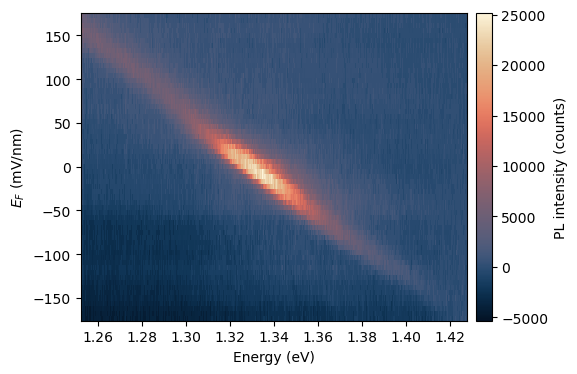

In [3]:
tmdc.plotting.plot_spectral_map(scan, cmap = "cmc.lipari")

# Exporting to hdf5 and exploring the file

Here we save the dataset to hdf5 with the same name, just with the `.h5` extension.

In [4]:
h5_path = Path(scan.path).with_suffix(".h5") 
scan.to_hdf5(h5_path, overwrite = True)

WindowsPath('data/stark-shift/PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.h5')

We demonstrate one of the clearest advantages of using HDF5: it's more space efficient.

In [5]:
csv_path = Path(scan.path)

csv_mb = csv_path.stat().st_size / 1e6
h5_mb  = h5_path.stat().st_size / 1e6

with h5py.File(h5_path, "r") as hf:
    arrays_bytes = 0
    def add(name, obj):
        global arrays_bytes
        if isinstance(obj, h5py.Dataset):
            arrays_bytes += obj.size * obj.dtype.itemsize
    hf.visititems(add)

print(f"CSV on disk      : {csv_mb:6.2f} MB")
print(f"arrays in memory : {arrays_bytes/1e6:6.2f} MB")
print(f"HDF5 on disk     : {h5_mb:6.2f} MB")
print(f"The HDF5 on disk is {csv_mb/h5_mb:.0f}x smaller than the CSV file with no data discarded.")

CSV on disk      :   4.59 MB
arrays in memory :   1.35 MB
HDF5 on disk     :   0.14 MB
The HDF5 on disk is 32x smaller than the CSV file with no data discarded.


4.59 → 1.35 MB is text becoming binary. In the CSV a single count like 613 is stored as characters, with a comma and often trailing zeros; in HDF5 it is one 8-byte float64. Most of the CSV is punctuation and digits, not information.

1.35 → 0.14 MB is the gzip compression that `to_hdf5` applies to the spectra by default. It works this well here because the array is mostly a flat ~613-count pedestal, so there is very little variation for the compressor to encode. A noisier dataset will not shrink by as much.

The HDF5 file is smaller than the arrays in memory because of compression. It is also smaller on disk than the CSV file, but it contains *more* information because we retain our physical gate mapping and sample geometry.

Now we walk through the structure of the hdf5 file.

In [6]:
with h5py.File(h5_path, "r") as hf:
    print(list(hf.keys()))

['axes', 'metadata', 'parameters', 'spectra']


We can also look at the groups and datasets available. We can infer the following: the wavelength data has `1340` points and we took `61` points in our electric field sweep. So the total dataset shape is `(1340,61)`

In [7]:
with h5py.File(h5_path, "r") as hf:
    def show(name, obj):
        kind = "Group" if isinstance(obj, h5py.Group) else f"Dataset {obj.shape} {obj.dtype}"
        print(f"{name:35s} {kind}")
    hf.visititems(show)

axes                                Group
axes/wavelength                     Dataset (1340,) float64
metadata                            Group
metadata/geometry                   Group
metadata/geometry/tmdc_stack        Dataset (2,) [('material', 'O'), ('n_layers', '<i4'), ('d_monolayer', '<f8'), ('eps', '<f8')]
parameters                          Group
parameters/33600A_Ch1_Vdc           Dataset (61,) float64
parameters/33600A_Ch1_Vpp           Dataset (61,) float64
parameters/33600A_Ch1_freq          Dataset (61,) float64
parameters/33600A_Ch2_Vdc           Dataset (61,) float64
parameters/33600A_Ch2_Vpp           Dataset (61,) float64
parameters/33600A_Ch2_freq          Dataset (61,) float64
parameters/Excitation Power         Dataset (61,) float64
parameters/Fianium_Laser_Power      Dataset (61,) float64
parameters/Fianium_Select_A0        Dataset (61,) float64
parameters/Fianium_Select_A1        Dataset (61,) float64
parameters/Fianium_Select_A2        Dataset (61,) float64
para

We also retain our loaded sample geometry

In [8]:
with h5py.File(h5_path, "r") as hf:
    g = hf["metadata/geometry"]

    print(f"top hBN    : {g.attrs['d_hbn_top']:.1f} nm")
    print(f"bottom hBN : {g.attrs['d_hbn_bottom']:.1f} nm")
    print(f"eps_hbn    : {g.attrs['eps_hbn']:.2f}")

    print("\nTMDC stack, in physical order from the top:")
    for row in g["tmdc_stack"][()]:
        print(f"  {row['material'].decode():8s} n_layers={row['n_layers']}  "
              f"d_monolayer={row['d_monolayer']:.3f} nm  eps={row['eps']:.2f}")

top hBN    : 53.0 nm
bottom hBN : 46.0 nm
eps_hbn    : 3.90

TMDC stack, in physical order from the top:
  MoSe2    n_layers=1  d_monolayer=0.650 nm  eps=7.20
  WSe2     n_layers=1  d_monolayer=0.650 nm  eps=7.40


We can also load the attributes, which are scalars that describe the measurement (and not the data itself!). The attributes related to the measurement sit in `/metadata`.

In [9]:
with h5py.File(h5_path, "r") as hf:
    print(dict(hf.attrs))                    # format, format_version, created, toolkit_version
    print(dict(hf["metadata"].attrs))        # spectra_type, sweep_type, gates, curated_units, ...

{'created': '2026-08-21T13:32:38.046579+02:00', 'format': 'tmdc_optics_tools.attocube_sweep', 'format_version': '2.3', 'toolkit_version': '0.1.0'}
{'apply_jacobian': np.True_, 'axis_kind': 'wavelength', 'bg_region_nm': array([861.00137801, 873.12815798]), 'curated_labels': '{"v_top": "V_A", "v_bot": "V_B", "power": "Excitation Power", "i_top": "I_A", "i_bot": "I_B", "i_channel": null, "scanner_x": "Scanner X", "scanner_y": "Scanner Y"}', 'curated_scales': '{"v_top": 1.0, "v_bot": 1.0, "power": 303000.0, "i_top": 1000000000.0, "i_bot": 1000000000.0, "i_channel": 1000000000.0, "scanner_x": 1.0, "scanner_y": 1.0}', 'curated_units': '{"v_top": "V", "v_bot": "V", "power": "\\u00b5W", "i_top": "nA", "i_bot": "nA", "i_channel": "nA", "scanner_x": "V", "scanner_y": "V"}', 'gates': '{"top": "V_A", "bottom": "V_B"}', 'roi': np.int64(1), 'source_file': 'data\\stark-shift\\PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.csv', 'spectra_type': 'PL', 'sweep_label': '$E_F$', 'sweep_type': 'electric_field'

and all our parameters

In [10]:
with h5py.File(h5_path, "r") as hf:
    parameter_handle = hf["parameters"]        # no data read yet
    print(parameter_handle.keys())

<KeysViewHDF5 ['33600A_Ch1_Vdc', '33600A_Ch1_Vpp', '33600A_Ch1_freq', '33600A_Ch2_Vdc', '33600A_Ch2_Vpp', '33600A_Ch2_freq', 'Excitation Power', 'Fianium_Laser_Power', 'Fianium_Select_A0', 'Fianium_Select_A1', 'Fianium_Select_A2', 'Fianium_Select_A3', 'Fianium_Select_A4', 'Fianium_Select_A5', 'Fianium_Select_A6', 'Fianium_Select_A7', 'Fianium_Select_W0', 'Fianium_Select_W1', 'Fianium_Select_W2', 'Fianium_Select_W3', 'Fianium_Select_W4', 'Fianium_Select_W5', 'Fianium_Select_W6', 'Fianium_Select_W7', 'Fianium_Varia_Bandwidth', 'Fianium_Varia_Central_Wavelength', 'Fianium_Varia_ND', 'Galvo_X', 'Galvo_Y', 'I_A', 'I_B', 'NKT - Pulse Picker Ratio', 'PD_V', 'PG1072_Frequency', 'PG1072_PulseDelay', 'PG1072_PulseWidth', 'PG1072_V_High', 'PG1072_V_Low', 'Picoharp - Actual Measurement Time', 'Picoharp - Counts', 'Picoharp - RepRate', 'Rotation Axis - Value', 'SR865_AUX4', 'SR865_R', 'SR865_T', 'Scanner X', 'Scanner Y', 'Solstis - Actual Wavelength from Wavemeter', 'Solstis - Target Wavelength', '

We can load our wavelength axis taken with the spectrometer.

In [11]:
with h5py.File(h5_path, "r") as hf:
    wl_handle = hf["axes/wavelength"]        # no data read yet
    print(wl_handle.shape, wl_handle.dtype, wl_handle.attrs["units"])
    wavelength = wl_handle[()]               # now it's a numpy array

print(wavelength[:10])

(1340,) float64 nm
[868.5724  868.66526 868.75812 868.85098 868.94383 869.03668 869.12953
 869.22237 869.31521 869.40805]


Our spectral data and the background region we used in the original scan. Here, we demonstrate one of the key feature of HDF5 by loading only *part* of the array.

In [12]:
with h5py.File(h5_path, "r") as hf:
    spectra_handle = hf["spectra/roi1"]        # no data read yet
    print(spectra_handle.shape, spectra_handle.dtype, spectra_handle.attrs["units"])
    part = spectra_handle[600:640, :]          # reads ~19 KiB, not the full 639 KiB
    print(part.shape, f"{part.nbytes/1024:.0f} KiB")
    spectra = spectra_handle[()]               # now we load the whole array, 639 KiB

    bg_region = hf["metadata"].attrs["bg_region_nm"]
    print("bg_region_nm:", bg_region)

(1340, 61) float64 counts
(40, 61) 19 KiB
bg_region_nm: [861.00137801 873.12815798]


We could plot our data using this hdf5 format to recreate what we saw in `/examples/example-stark-shift.ipynb`. We first calculate our electric field

In [13]:
with h5py.File(h5_path, "r") as hf:
    v_top_handle = hf["parameters/V_A"][()] # Read the data
    v_bot_handle = hf["parameters/V_B"][()] # Read the data

E_field = sample_geometry.electric_field(v_top_handle, v_bot_handle)

from tmdc_optics_tools.constants import HC_EV_NM

energy = HC_EV_NM / wavelength
print(energy[:10])

[1.42744806 1.42729546 1.4271429  1.42699037 1.42683789 1.42668545
 1.42653303 1.42638067 1.42622833 1.42607603]


Our spectral data has a cosmic rays which skews the colourbar. There are two ways around this
1. Remove the cosmic rays with a processing step 
2. Plot the map with different colorbar bounds.

In [14]:
# remove_cosmic_rays returns the repaired array and a mask of what it changed.
# axis=0 is the pixel axis, which is how the file stores it.
clean, cr_mask = processing.remove_cosmic_rays(spectra, axis=0)
print(f"{cr_mask.sum()} pixels repaired")

29 pixels repaired


Text(0, 0.5, 'Electric field (mV/nm)')

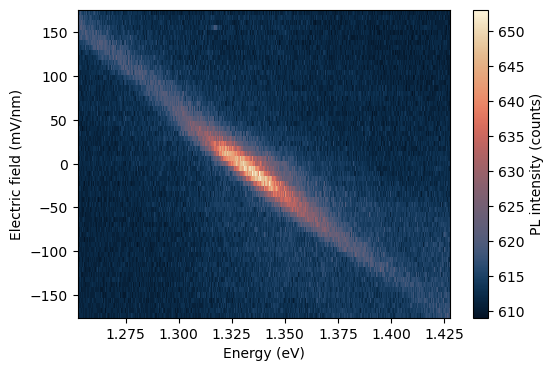

In [15]:
fig, ax = plt.subplots(figsize = (6, 4))

mesh = ax.pcolormesh(energy, E_field, clean.T, cmap="cmc.lipari", shading="auto")
fig.colorbar(mesh, ax=ax, label="PL intensity (counts)")

ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Electric field (mV/nm)")

Alternatively, scaling the colorbar:

Text(0, 0.5, 'Electric field (mV/nm)')

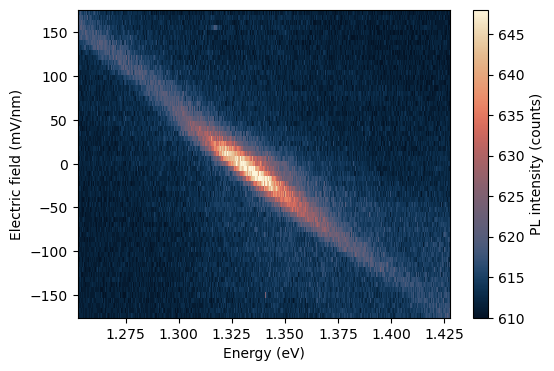

In [16]:
fig, ax = plt.subplots(figsize = (6, 4))

mesh = ax.pcolormesh(energy, E_field, spectra.T, cmap="cmc.lipari", shading="auto",
              vmin=np.percentile(spectra, 1), vmax=np.percentile(spectra, 99.9))
fig.colorbar(mesh, ax=ax, label="PL intensity (counts)")

ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Electric field (mV/nm)")

## Reading back the hdf5 file

We've shown how to inspect the `.h5` file, but for our purposes, it's easier to read back the `.h5` file into our `AttoCubeSpectralSweep` class because we can take advantage of the class structure which naturally interfaces with the other modules.

When we export the `.h5` file and load it back, corrections are not applied by default. This is a deliberate design choice. To apply our background subtraction and jacobian, we have to declare so:

In [17]:
scan_h5 = tmdc.AttoCubeSpectralSweep(
    path = h5_path,
    bg_region_eV = (1.42,1.44),                    # Applies background subtraction in eV with provided range as the window. Must be used if apply_jacobian = True
    apply_jacobian = True
)

print(scan_h5)

AttoCubeSpectralSweep — 61 sweeps × 1340 pixels  [Photoluminescence]
  File        : data\stark-shift\PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.h5
  λ range     : 868.6 – 989.9 nm
  Energy range: 1.252 – 1.427 eV
  Sweep       : electric_field — -173 → 173 mV/nm
  Gates       : dual-gate, anti-correlated (field-like)  (top ← 'V_A', bottom ← 'V_B')
  Power       : 56.0 → 56.6 µW
  Varying     : I_B, I_A, V_A, V_B
  ROI         : ExpROI1
  BG region   : 861.0 – 873.1 nm
  Jacobian    : applied



When we read back our `.h5` file, we retain our sample geometry and the gate mapping

In [18]:
scan_h5.geometry

DeviceGeometry
  hBN top       : 53.0 nm
  TMDC stack    : StackLayer(MoSe2, n_layers=1, d=0.650 nm, ε=7.2) / StackLayer(WSe2, n_layers=1, d=0.650 nm, ε=7.4)
  hBN bottom    : 46.0 nm
  ε_stack       : 3.9237
  ε_2D          : 7.2986
  d_stack       : 100.30 nm
  d_2D          : 1.30 nm

In [19]:
scan_h5.gates

{'top': 'V_A', 'bottom': 'V_B'}

Then we check that our roundtrip is indeed lossless:

In [20]:
print("raw spectra identical  :", np.allclose(scan.spectra, scan_h5.spectra))
print("corrected map identical:", np.allclose(scan.energy_spectra_bg, scan_h5.energy_spectra_bg))
print("field axis identical   :", np.allclose(scan.ef, scan_h5.ef))

raw spectra identical  : True
corrected map identical: True
field axis identical   : True


With this, it's trivial to plot our spectral map with all the corrections we want.

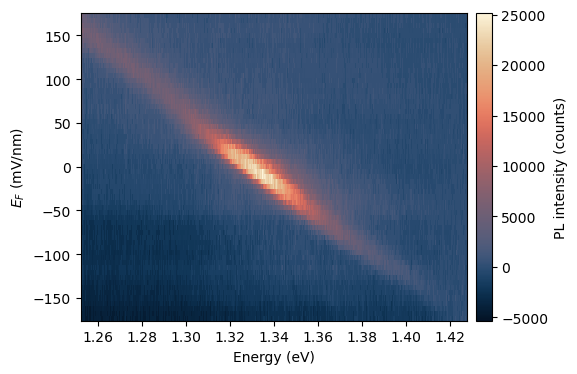

In [21]:
fig, ax, mesh = tmdc.plotting.plot_spectral_map(
    scan = scan_h5,         # The scan object
    x_axis = "energy",   # Optional. The x-axis to plot. Can be "energy" or "wavelength". Defaults to "energy".
    rescale_img = False, # Optional. If True, rescales intensity to [0, 1] before plotting. Defaults to False.
    cmap = "cmc.lipari",
)